In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path

relative_path = Path("data/authorization/authorization_training_15000.csv")
csv_path = next(
    (base / relative_path for base in [Path.cwd(), *Path.cwd().parents]
     if (base / relative_path).is_file()),
    None
)

if csv_path is None:
    raise FileNotFoundError(f"Could not locate {relative_path.resolve()}")

df = pd.read_csv(csv_path)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (15000, 17)


,authorization_id,patient_id,provider_id,request_date,authorization_type,service_code,service_description,requested_quantity,charged_amount,approval_status,approval_date,valid_from_date,valid_to_date,reference_number,payer_id,diagnosis_code,notes
0,AUTH00001-2026A,PAT58368,PRV4993,2025-03-31,medication,NDC43598-0545-01,Albuterol inhaler,2,187.35,approved,2025-04-04,2025-04-01,2025-05-01,REF-PA-350001,PAY7686,J45.909,Request submitted for review
1,AUTH00002-2026A,PAT25525,PRV8245,2025-12-05,DME,HCPCS E0165,Commode chair,1,338.48,approved,2025-12-11,2025-12-07,2026-06-05,REF-PA-350002,PAY6942,R26.89,Request submitted for review
2,AUTH00003-2026A,PAT35112,PRV3165,2026-02-04,procedure,CPT99214,"Office visit, established patient",1,362.78,approved,2026-02-06,2026-02-06,2026-08-05,REF-PA-350003,PAY2627,E78.5,Standard authorization request
3,AUTH00004-2026A,PAT42177,PRV4073,2026-04-14,DME,HCPCS E0607,CPAP device,1,2007.68,denied,2026-04-16,2026-04-16,2026-06-15,REF-PA-350004,PAY7367,G47.33,Medical necessity criteria not met
4,AUTH00005-2026A,PAT71433,PRV3634,2025-01-27,procedure,CPT29881,Knee arthroscopy with meniscectomy,1,5304.87,approved,2025-02-03,2025-01-27,2025-03-28,REF-PA-350005,PAY8432,M23.21,Clinical review in progress


In [5]:
df_raw = df.copy()

print("Raw dataset backup created successfully.")

Raw dataset backup created successfully.


In [6]:
print("DATASET INFORMATION")
print("=" * 50)

print("\nShape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
df.info()

DATASET INFORMATION

Shape:
(15000, 17)

Column Names:
['authorization_id', 'patient_id', 'provider_id', 'request_date', 'authorization_type', 'service_code', 'service_description', 'requested_quantity', 'charged_amount', 'approval_status', 'approval_date', 'valid_from_date', 'valid_to_date', 'reference_number', 'payer_id', 'diagnosis_code', 'notes']

Data Types:
authorization_id        object
patient_id              object
provider_id             object
request_date            object
authorization_type      object
service_code            object
service_description     object
requested_quantity       int64
charged_amount         float64
approval_status         object
approval_date           object
valid_from_date         object
valid_to_date           object
reference_number        object
payer_id                object
diagnosis_code          object
notes                   object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Da

In [7]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
].sort_values("Missing_Count", ascending=False)

print(missing_summary)

               Missing_Count  Missing_Percentage
approval_date           2201           14.673333


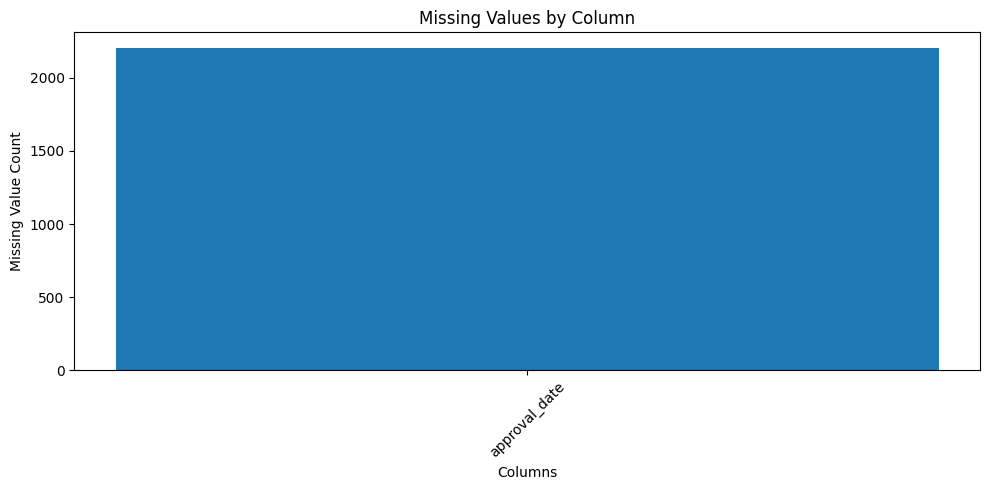

In [8]:
if not missing_summary.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(
        missing_summary.index,
        missing_summary["Missing_Count"]
    )
    plt.title("Missing Values by Column")
    plt.xlabel("Columns")
    plt.ylabel("Missing Value Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

In [9]:
duplicate_count = df.duplicated().sum()

print("Total Duplicate Rows:", duplicate_count)

Total Duplicate Rows: 0


In [10]:
duplicate_rows = df[df.duplicated(keep=False)]

print("Duplicate Records:")
print(duplicate_rows.head())

Duplicate Records:
Empty DataFrame
Columns: [authorization_id, patient_id, provider_id, request_date, authorization_type, service_code, service_description, requested_quantity, charged_amount, approval_status, approval_date, valid_from_date, valid_to_date, reference_number, payer_id, diagnosis_code, notes]
Index: []


In [11]:
unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique_Values": [df[col].nunique(dropna=False) for col in df.columns]
})

unique_summary

,Column,Unique_Values
0,authorization_id,15000
1,patient_id,994
2,provider_id,247
3,request_date,546
4,authorization_type,4
5,service_code,21
6,service_description,21
7,requested_quantity,64
8,charged_amount,13844
9,approval_status,4


In [12]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print("\n" + "=" * 60)
    print(f"COLUMN: {col}")
    print("=" * 60)
    
    print(df[col].value_counts(dropna=False).head(20))


COLUMN: authorization_id
authorization_id
AUTH00001-2026A    1
AUTH10005-2026A    1
AUTH09993-2026A    1
AUTH09994-2026A    1
AUTH09995-2026A    1
AUTH09996-2026A    1
AUTH09997-2026A    1
AUTH09998-2026A    1
AUTH09999-2026A    1
AUTH10000-2026A    1
AUTH10001-2026A    1
AUTH10002-2026A    1
AUTH10003-2026A    1
AUTH10004-2026A    1
AUTH10006-2026A    1
AUTH10020-2026A    1
AUTH10007-2026A    1
AUTH10008-2026A    1
AUTH10009-2026A    1
AUTH10010-2026A    1
Name: count, dtype: int64

COLUMN: patient_id
patient_id
PAT82512    41
PAT80010    38
PAT24168    33
PAT96951    31
PAT98039    31
PAT37760    27
PAT47093    26
PAT56438    26
PAT47828    26
PAT98781    26
PAT99166    26
PAT63264    26
PAT84085    26
PAT41029    25
PAT44760    25
PAT56112    25
PAT62521    25
PAT55082    24
PAT57576    24
PAT82350    24
Name: count, dtype: int64

COLUMN: provider_id
provider_id
PRV8451    116
PRV7807    111
PRV5835    101
PRV2713     79
PRV1659     79
PRV6439     78
PRV3588     78
PRV6403     77
P

In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
requested_quantity,15000.0,15.012667,26.518583,1.0,1.0000,1.000,3.0000,90.00
charged_amount,15000.0,2475.396027,9178.084770,15.0,123.1125,372.935,2322.4625,155910.46


In [14]:
outlier_summary = []

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()
    
    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Potential_Outliers": outlier_count
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df

,Column,Q1,Q3,Lower_Bound,Upper_Bound,Potential_Outliers
0,requested_quantity,1.0000,3.0000,-2.0000,6.0000,3531
1,charged_amount,123.1125,2322.4625,-3175.9125,5621.4875,765


In [15]:
special_char_summary = []

for col in categorical_cols:
    
    non_null_values = df[col].dropna().astype(str)
    
    special_char_mask = non_null_values.str.contains(
        r'[^a-zA-Z0-9\s\-_./]',
        regex=True
    )
    
    special_count = special_char_mask.sum()
    
    special_char_summary.append({
        "Column": col,
        "Special_Character_Count": special_count
    })

special_char_df = pd.DataFrame(special_char_summary)

special_char_df

,Column,Special_Character_Count
0,authorization_id,0
1,patient_id,0
2,provider_id,0
3,request_date,0
4,authorization_type,0
5,service_code,0
6,service_description,3554
7,approval_status,0
8,approval_date,0
9,valid_from_date,0


In [16]:
for col in categorical_cols:
    
    mask = (
        df[col]
        .dropna()
        .astype(str)
        .str.contains(r'[^a-zA-Z0-9\s\-_./]', regex=True)
    )
    
    suspicious_values = df.loc[
        df[col].notna() & 
        df[col].astype(str).str.contains(
            r'[^a-zA-Z0-9\s\-_./]', regex=True
        ),
        col
    ]
    
    if len(suspicious_values) > 0:
        print(f"\nSpecial characters found in: {col}")
        print(suspicious_values.head(10).tolist())


Special characters found in: service_description
['Office visit, established patient', 'Office visit, high complexity', 'Office visit, high complexity', 'Office visit, high complexity', 'Electrocardiogram, routine', 'Electrocardiogram, routine', 'Office visit, established patient', 'Office visit, established patient', 'Electrocardiogram, routine', 'Crutches, forearm']


In [17]:
date_cols = [
    "request_date",
    "approval_date",
    "valid_from_date",
    "valid_to_date"
]

for col in date_cols:
    print(f"\nChecking: {col}")
    
    converted_dates = pd.to_datetime(
        df[col],
        errors="coerce"
    )
    
    invalid_date_count = (
        df[col].notna() & converted_dates.isna()
    ).sum()
    
    missing_date_count = df[col].isna().sum()
    
    print("Missing Dates:", missing_date_count)
    print("Invalid Dates:", invalid_date_count)


Checking: request_date
Missing Dates: 0
Invalid Dates: 0

Checking: approval_date
Missing Dates: 2201
Invalid Dates: 0

Checking: valid_from_date
Missing Dates: 0
Invalid Dates: 0

Checking: valid_to_date
Missing Dates: 0
Invalid Dates: 0


In [18]:
for col in numeric_cols:
    
    negative_count = (df[col] < 0).sum()
    
    if negative_count > 0:
        print(f"{col}: {negative_count} negative values found")

In [19]:
empty_summary = []

for col in categorical_cols:
    
    empty_count = (
        df[col]
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )
    
    whitespace_count = (
        df[col]
        .notna() &
        df[col]
        .astype(str)
        .str.contains(r'^\s+$', regex=True)
    ).sum()
    
    empty_summary.append({
        "Column": col,
        "Empty_String_Count": empty_count,
        "Whitespace_Only_Count": whitespace_count
    })

empty_df = pd.DataFrame(empty_summary)

empty_df[
    (empty_df["Empty_String_Count"] > 0) |
    (empty_df["Whitespace_Only_Count"] > 0)
]

,Column,Empty_String_Count,Whitespace_Only_Count


In [22]:
df_ml = df.copy()

print("ML preprocessing dataset created.")
print("Shape:", df_ml.shape)

ML preprocessing dataset created.
Shape: (15000, 17)


In [23]:
output_path = "preprocessed_authorization_data.csv"

df_ml.to_csv(output_path, index=False)

print(f"Preprocessed data saved successfully as: {output_path}")
print("Shape:", df_ml.shape)

Preprocessed data saved successfully as: preprocessed_authorization_data.csv
Shape: (15000, 17)
